# NASA Pulsar Star Classification (Non-Linear SVM)

**Project Description:** This model classifies deep-space radio signals recorded by the HTRU2 survey as either Cosmic Noise (0) or genuine Pulsar Stars (1), based on statistical features of the pulse profile and DM-SNR curve. Pulsars are rare, rapidly rotating neutron stars that emit periodic radio signals — detecting them reliably in noisy data is a classic imbalanced binary classification problem.

**Algorithm:** It utilizes a **Support Vector Machine (SVM)** with an **RBF (Radial Basis Function) kernel**, which maps the 8-dimensional feature space into a higher-dimensional space where a non-linear decision boundary cleanly separates the two classes. GridSearchCV is used to tune the key hyperparameters `C` and `gamma` for optimal F1-Score performance.

Step 1: Import the Libraries

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [42]:
%matplotlib inline

Step 2: Import the Dataset

In [43]:
column_names = [
    'mean_profile', 'std_profile', 'kurtosis_profile', 'skewness_profile',
    'mean_dmsnr', 'std_dmsnr', 'kurtosis_dmsnr', 'skewness_dmsnr', 'target'
]
df = pd.read_csv('Dataset/HTRU_2.csv', header=None, names=column_names)

In [44]:
df.head()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [45]:
df.shape

(17898, 9)

In [46]:
df.isnull().sum()

mean_profile        0
std_profile         0
kurtosis_profile    0
skewness_profile    0
mean_dmsnr          0
std_dmsnr           0
kurtosis_dmsnr      0
skewness_dmsnr      0
target              0
dtype: int64

In [47]:
print(f'Pulsar Stars  (1): {(df["target"] == 1).sum()}')
print(f'Cosmic Noise  (0): {(df["target"] == 0).sum()}')
print(f'Pulsar ratio     : {df["target"].mean() * 100:.2f}%')

Pulsar Stars  (1): 1639
Cosmic Noise  (0): 16259
Pulsar ratio     : 9.16%


Step 3: Separate Features and Target Variable

In [48]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [49]:
print(X.shape, y.shape)

(17898, 8) (17898,)


Step 4: Split the Dataset into Training and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Step 5: Feature Scaling (Crucial for SVM!)

In [51]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Step 6: Visualize the Dataset in 2D (PCA Projection)

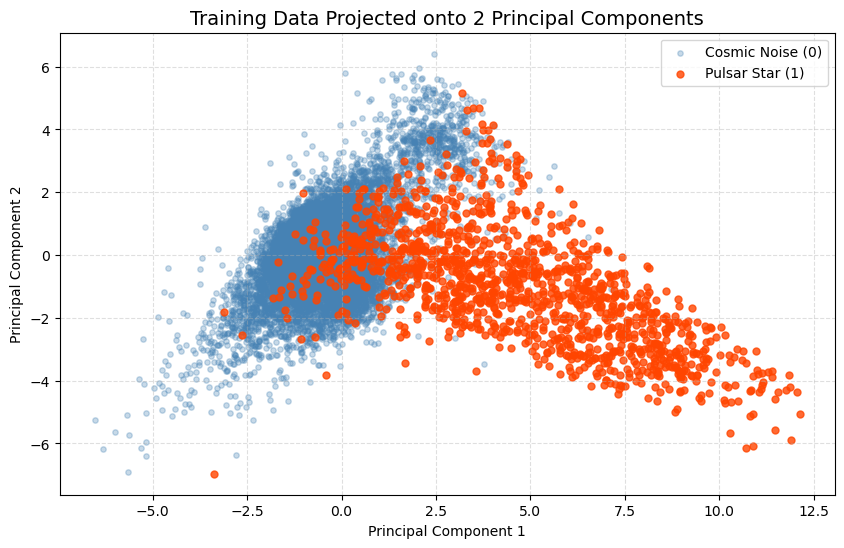

In [52]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

pc1 = X_train_pca[:, 0]
pc2 = X_train_pca[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(pc1[y_train == 0], pc2[y_train == 0],
            c='steelblue', alpha=0.3, s=15, label='Cosmic Noise (0)')
plt.scatter(pc1[y_train == 1], pc2[y_train == 1],
            c='orangered', alpha=0.8, s=25, label='Pulsar Star (1)')
plt.title('Training Data Projected onto 2 Principal Components', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Step 7: Train the SVM Model (Default RBF Kernel)

In [53]:
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Step 8: Evaluate the Model — Confusion Matrix & Classification Report

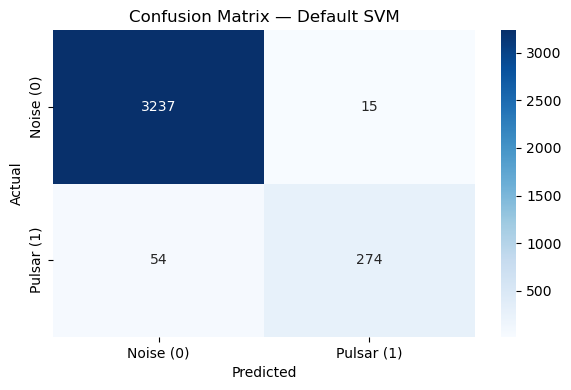

In [54]:
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Noise (0)', 'Pulsar (1)'],
            yticklabels=['Noise (0)', 'Pulsar (1)'])
plt.title('Confusion Matrix — Default SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [55]:
print(classification_report(y_test, y_pred, target_names=['Noise (0)', 'Pulsar (1)']))

              precision    recall  f1-score   support

   Noise (0)       0.98      1.00      0.99      3252
  Pulsar (1)       0.95      0.84      0.89       328

    accuracy                           0.98      3580
   macro avg       0.97      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



Step 9: ROC AUC Score & Curve (Default Model)

ROC AUC Score (Default Model): 0.9542


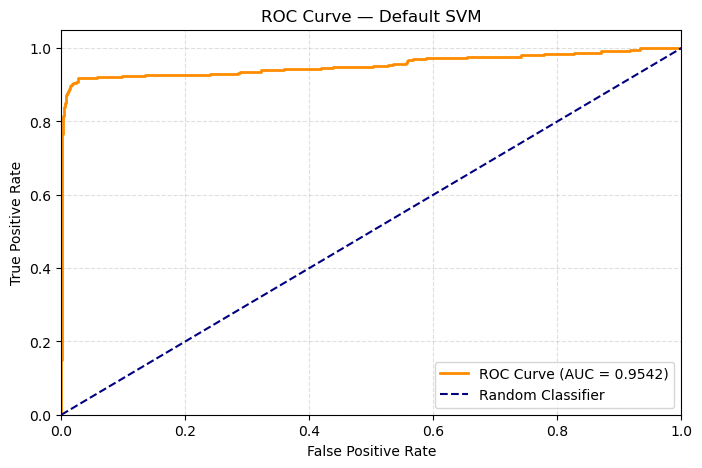

In [56]:
model_prob = SVC(kernel='rbf', random_state=42, probability=True)
model_prob.fit(X_train_scaled, y_train)
y_prob = model_prob.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC AUC Score (Default Model): {roc_auc:.4f}')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Default SVM')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Step 10: Visualize Non-Linear SVM Decision Boundary (Default Model)

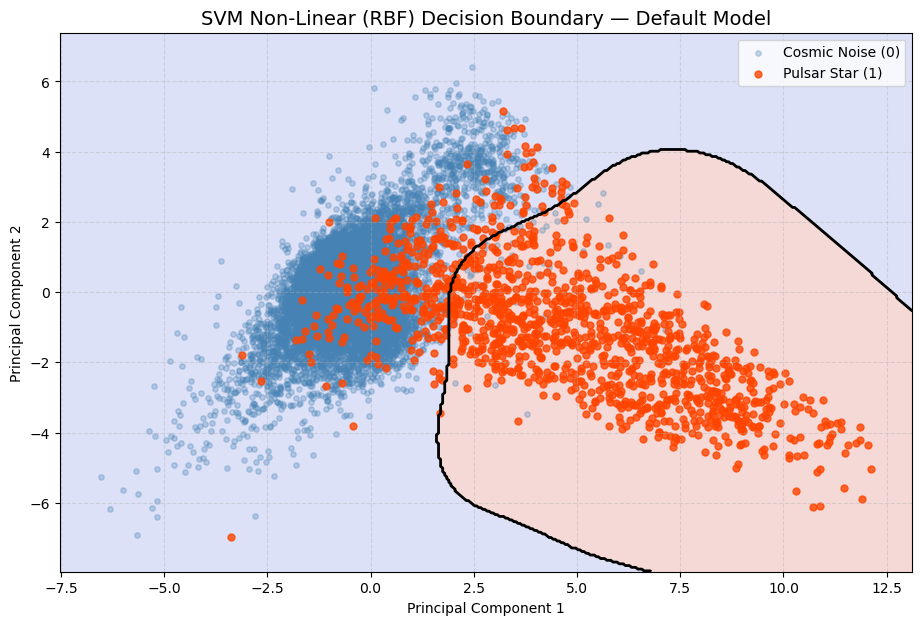

In [57]:
model_2d = SVC(kernel='rbf', random_state=42)
model_2d.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(11, 7))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
plt.contour(xx, yy, Z, colors='k', linewidths=2, levels=[0.5])
plt.scatter(pc1[y_train == 0], pc2[y_train == 0],
            c='steelblue', label='Cosmic Noise (0)', alpha=0.3, s=15)
plt.scatter(pc1[y_train == 1], pc2[y_train == 1],
            c='orangered', label='Pulsar Star (1)', alpha=0.8, s=25)
plt.title('SVM Non-Linear (RBF) Decision Boundary — Default Model', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Step 11: Hyperparameter Tuning with GridSearchCV

In [58]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
print('Best Parameters Found:', grid.best_params_)

Best Parameters Found: {'C': 10, 'class_weight': None, 'gamma': 'scale'}


Step 12: Evaluate the Tuned Model — Confusion Matrix & Classification Report

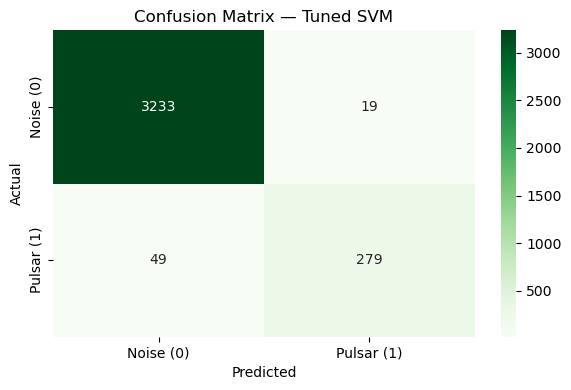

In [59]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Noise (0)', 'Pulsar (1)'],
            yticklabels=['Noise (0)', 'Pulsar (1)'])
plt.title('Confusion Matrix — Tuned SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [60]:
print(classification_report(y_test, y_pred_tuned, target_names=['Noise (0)', 'Pulsar (1)']))

              precision    recall  f1-score   support

   Noise (0)       0.99      0.99      0.99      3252
  Pulsar (1)       0.94      0.85      0.89       328

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



Step 13: ROC AUC Score & Curve (Tuned Model)

ROC AUC Score (Tuned Model): 0.9417


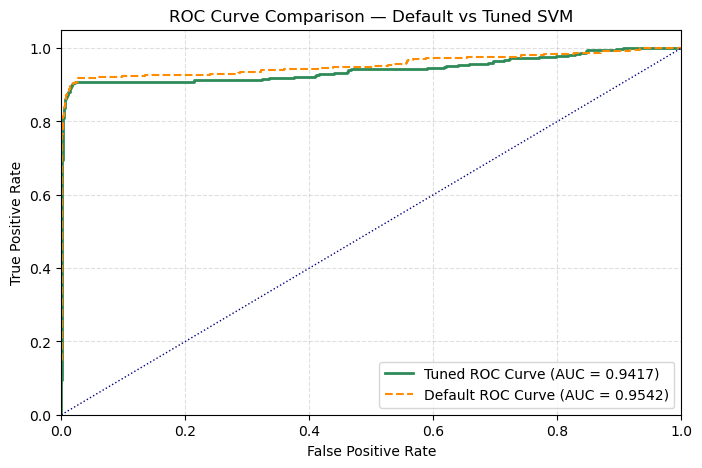

In [61]:
best_model_prob = SVC(**{k: v for k, v in grid.best_params_.items()},
                      kernel='rbf', random_state=42, probability=True)
best_model_prob.fit(X_train_scaled, y_train)
y_prob_tuned = best_model_prob.predict_proba(X_test_scaled)[:, 1]

roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
print(f'ROC AUC Score (Tuned Model): {roc_auc_tuned:.4f}')

fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(8, 5))
plt.plot(fpr_t, tpr_t, color='seagreen', lw=2,
         label=f'Tuned ROC Curve (AUC = {roc_auc_tuned:.4f})')
plt.plot(fpr, tpr, color='darkorange', lw=1.5, linestyle='--',
         label=f'Default ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Default vs Tuned SVM')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Step 14: Visualize Non-Linear SVM Decision Boundary (Tuned Model)

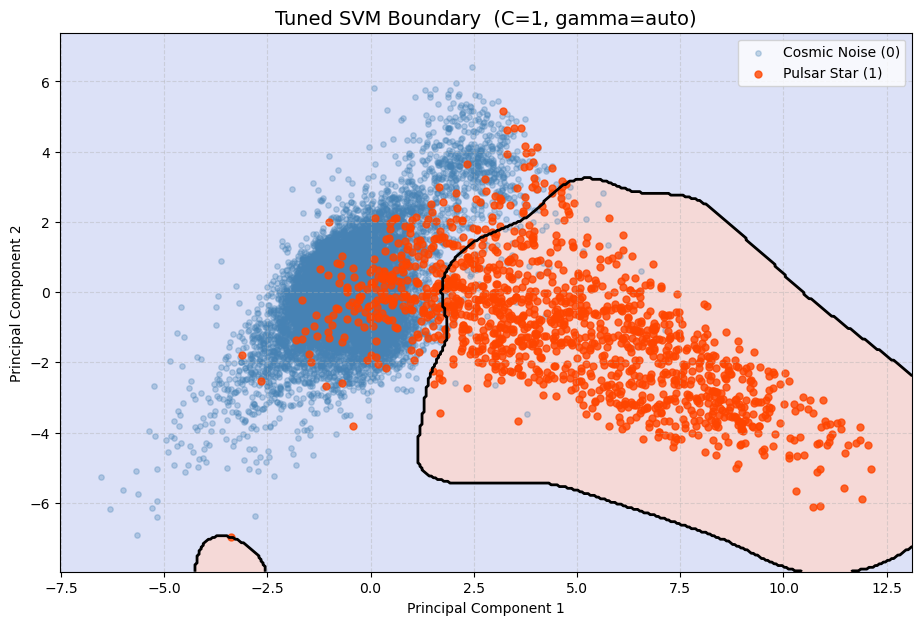

In [62]:
grid_2d = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_2d.fit(X_train_pca, y_train)
best_model_2d = grid_2d.best_estimator_

Z_tuned = best_model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(11, 7))
plt.contourf(xx, yy, Z_tuned, alpha=0.2, cmap=plt.cm.coolwarm)
plt.contour(xx, yy, Z_tuned, colors='k', linewidths=2, levels=[0.5])
plt.scatter(pc1[y_train == 0], pc2[y_train == 0],
            c='steelblue', label='Cosmic Noise (0)', alpha=0.3, s=15)
plt.scatter(pc1[y_train == 1], pc2[y_train == 1],
            c='orangered', label='Pulsar Star (1)', alpha=0.8, s=25)
plt.title(f'Tuned SVM Boundary  (C={best_model_2d.C}, gamma={best_model_2d.gamma})', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()